# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"


Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4/units/share/udunits/udunits2.xml

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3

### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021

census2021 <- read_csv("census2021_raw.csv")|>
    glimpse()


Rows: 1016 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Type
dbl (12): GeoUID, Region Name, Area (sq km), Population, Dwellings, Househol...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,016
Columns: 13
$ GeoUID                                                                <dbl> …
$ Type                                                                  <chr> …
$ `Region Name`                                                         <dbl> …
$ `Area (sq km)`                                                        <dbl> …
$ Population                                                            <dbl> …
$ Dwellings                                                             <dbl> …
$ Households                                                            <dbl> …
$ `v_CA21_1: Population, 2021`                                          <dbl> …
$ `v_CA21_6: Population density per square kilometre`                   <dbl> …
$ `v_CA21_386: Average age`                                             <dbl> …
$ `v_CA21_906: Median total income of household in 2020 ($)`            <dbl> …
$ `v_CA21_5853: University certificate or diploma above bachelor level` <dbl> …
$ `v_CA21_4410: 

In [3]:
census2021_clean <- census2021|>
    rename(name = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5853: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`)|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(university_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, area_sq_km, age, income, immigrant_prop, university_prop)|>
    glimpse()

census2021_clean$name <- as.character(census2021_clean$name)

Rows: 1,016
Columns: 10
$ name               <dbl> 59150307, 59150308, 59150309, 59150310, 59150311, 5…
$ households         <dbl> 266, 218, 282, 389, 187, 201, 355, 169, 350, 209, 3…
$ dwellings          <dbl> 297, 229, 299, 411, 202, 218, 368, 177, 369, 221, 3…
$ population         <dbl> 677, 541, 761, 748, 537, 555, 1003, 508, 966, 544, …
$ population_density <dbl> 2263.5, 4936.1, 6800.7, 6837.3, 6637.8, 6372.0, 580…
$ area_sq_km         <dbl> 0.2991, 0.1096, 0.1119, 0.1094, 0.0809, 0.0871, 0.1…
$ age                <dbl> 42.8, 43.0, 43.3, 37.0, 41.0, 40.6, 45.6, 41.4, 42.…
$ income             <dbl> 1.14, 1.14, 0.94, 0.67, 0.92, 0.96, 0.90, 0.95, 0.8…
$ immigrant_prop     <dbl> 0.2806499, 0.2957486, 0.2759527, 0.2606952, 0.28864…
$ university_prop    <dbl> 0.01477105, 0.04621072, 0.03285151, 0.01336898, 0.0…


### Data Exploration

In [4]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    rename("university_prop" = "education_prop")|>
    mutate(income = as.double(income),
    immigrant_prop = as.double(immigrant_prop),
    university_prop = as.double(university_prop))|>
    glimpse()

Warning message:
"There were 3 warnings in `stopifnot()`.
The first warning was:
ℹ In argument: `income = as.double(income)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings."


Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [5]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2024)|>
    glimpse()

Rows: 351,457
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [6]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 193,067
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


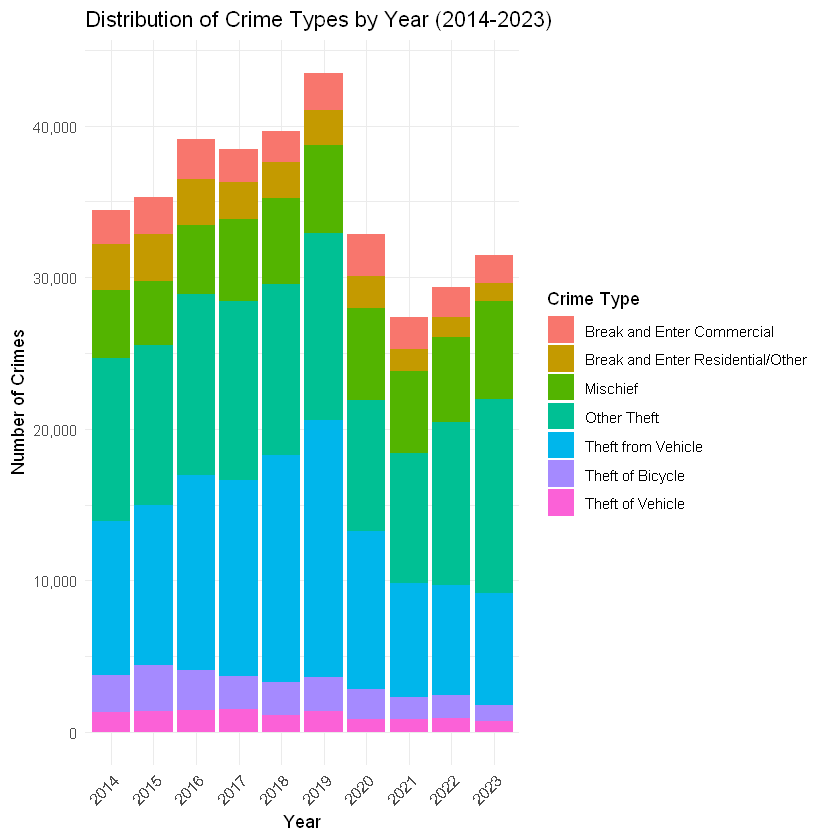

In [7]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [8]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 104,703
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [9]:
census2016_panel <- merge(census2016, crime_trend, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 104,703
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [10]:
census2016_2021_panel <- census2016_panel %>%
  left_join(census2021_clean, by = "name", suffix = c("", ".new")) |>
  mutate(
    # For each variable, if the date is on or after 2019-01-01, use the new (2021) data; otherwise keep the original
    households = if_else(date >= as.Date("2019-01-01"), households.new, households),
    dwellings = if_else(date >= as.Date("2019-01-01"), dwellings.new, dwellings),
    population = if_else(date >= as.Date("2019-01-01"), population.new, population),
    population_density = if_else(date >= as.Date("2019-01-01"), population_density.new, population_density),
    area_sq_km = if_else(date >= as.Date("2019-01-01"), area_sq_km.new, area_sq_km),
    age = if_else(date >= as.Date("2019-01-01"), age.new, age),
    income = if_else(date >= as.Date("2019-01-01"), income.new, income),
    immigrant_prop = if_else(date >= as.Date("2019-01-01"), immigrant_prop.new, immigrant_prop),
    university_prop = if_else(date >= as.Date("2019-01-01"), university_prop.new, university_prop)
  ) |>
  select(-ends_with(".new"))|>
  glimpse()


Rows: 104,703
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [11]:
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016_2021_panel <- st_make_valid(census2016_2021_panel)


# Compute centroids for census divisions
census2016_centroids <- st_centroid(census2016_2021_panel)

# Perform a spatial join based on whether the census centroid is within the neighborhood boundary
census2016_centroids_joined <- st_join(census2016_centroids, neighborhood_valid[, "neighborhood"], join = st_within)

census2016_2021_panel$neighborhood <- census2016_centroids_joined$neighborhood

glimpse(census2016_2021_panel)


Warning message:
"st_centroid assumes attributes are constant over geometries"


Rows: 104,703
Columns: 23
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

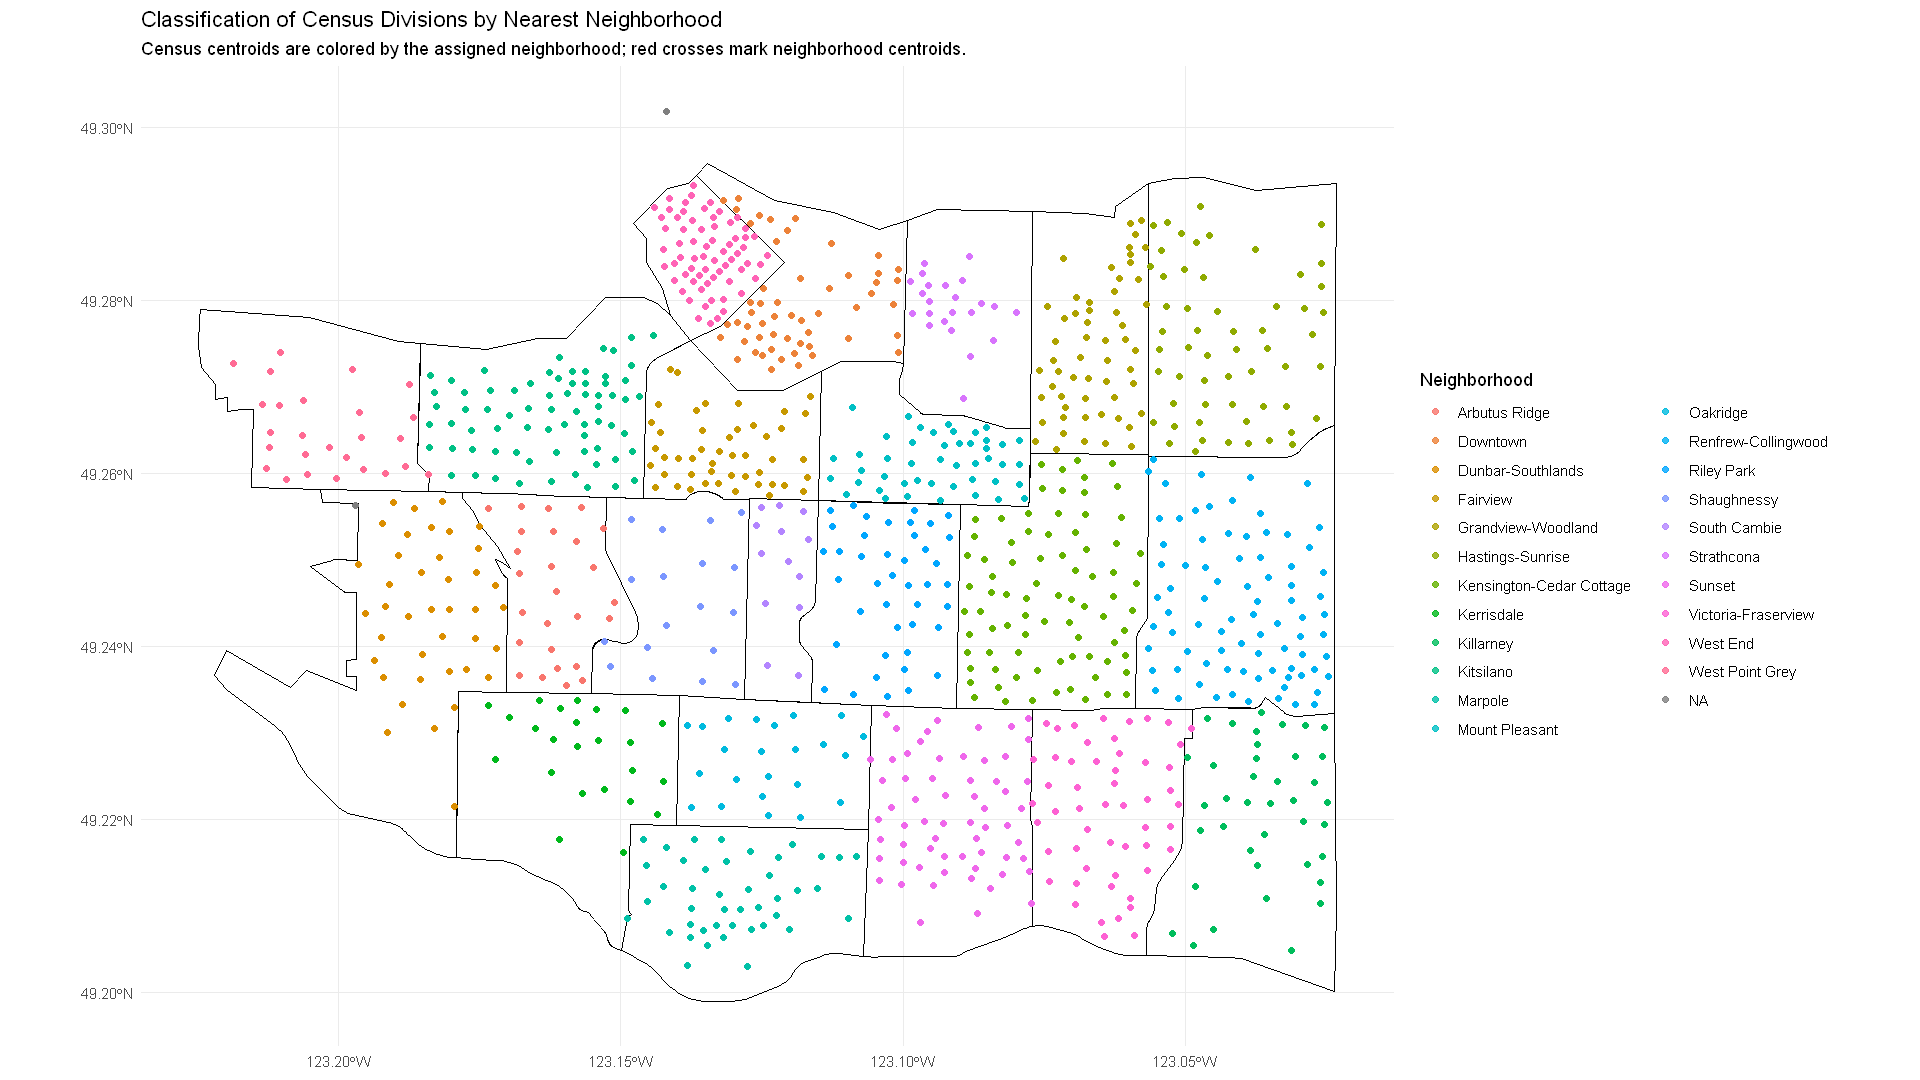

In [12]:
census2016_centroids <- census2016_centroids %>%
  mutate(neighborhood = census2016_2021_panel$neighborhood)

options(repr.plot.width = 16, repr.plot.height = 9)

# Create the plot of neighborhood
ggplot() +
  geom_sf(data = neighborhood_valid, fill = NA, color = "black", lwd = 0.5) +
  geom_sf(data = census2016_centroids, aes(color = neighborhood), size = 1.5, alpha = 0.8) +
  scale_fill_grey(start = 0.2, end = 0.9) + 
  labs(title = "Classification of Census Divisions by Nearest Neighborhood",
       subtitle = "Census centroids are colored by the assigned neighborhood; red crosses mark neighborhood centroids.",
       color = "Neighborhood") +
  theme_minimal()

In [13]:
# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [14]:
# Merge 2 dataframes
census2016_2021_panel <- census2016_2021_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 104,703
Columns: 27
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [15]:
crime_summary <- census2016_2021_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
2.843653,46.09844,1,198


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [16]:
census2016_2021_panel <- census2016_2021_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

Rows: 104,703
Columns: 28
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [17]:
census2016_2021_panel <- census2016_2021_panel|>
    filter(!is.na(population_density), !is.na(year), !is.na(month), !is.na(time_category))|>
    glimpse()

Rows: 102,664
Columns: 28
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [18]:
# load the necessary library
library(MASS)

# Coverting fixed effects as factors
census2016_2021_panel$name <- as.factor(census2016_2021_panel$name)
census2016_2021_panel$year <- as.factor(census2016_2021_panel$year)
census2016_2021_panel$month <- as.factor(census2016_2021_panel$month)
census2016_2021_panel$time_category <- as.factor(census2016_2021_panel$time_category)
census2016_2021_panel$neighborhood <- as.factor(census2016_2021_panel$neighborhood)

# Implementing the negative binomial regression
model_nb <- glm.nb(crime_count ~ name + year + month + time_category + offset(log(population_density)),
                   data = census2016_2021_panel)

summary(model_nb)

Warning message:
"package 'MASS' was built under R version 4.4.2"



Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
glm.nb(formula = crime_count ~ name + year + month + time_category + 
    offset(log(population_density)), data = census2016_2021_panel, 
    init.theta = 24.32163793, link = log)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -7.3275677  0.0809287 -90.544  < 2e-16 ***
name59150308       -0.8169120  0.1188183  -6.875 6.19e-12 ***
name59150309       -1.0838460  0.1048909 -10.333  < 2e-16 ***
name59150310       -0.7322792  0.0980043  -7.472 7.90e-14 ***
name59150311       -1.3204213  0.1196513 -11.036  < 2e-16 ***
name59150312       -1.2405453  0.1235541 -10.041  < 2e-16 ***
name59150313       -0.8647575  0.1104558  -7.829 4.92e-15 ***
name59150328       -0.1412629  0.1164947  -1.213 0.225278    
name59150329       -0.3936360  0.1113685  -3.535 0.000408 ***
name59150330       -1.3473804  0.1559236  -8.641  < 2e-16 ***
name59150331       -1.0012809  0.1198722  -8.353  < 2e-16 ***
name59150332       -1.2102562  0.1281144  -9.447  < 2e

In [19]:
census2016_2021_panel$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_2021_panel)

Rows: 102,664
Columns: 29
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [20]:
NBsummary <- census2016_2021_panel|>
    st_drop_geometry()|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,2.571807,24.58580,0.5399983,106.7988
night,2.674647,26.08789,0.6647206,131.4659


In [21]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [22]:
census2016_2021_panel <- census2016_2021_panel|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 102,664
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <dbl> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <dbl> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <dbl> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <dbl> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.84736, 0.45184, 0.82…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.3557047, 0.289…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.3154362, 0.186…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [23]:
# Save the data so we can start from here next time
census2016_2021_panel <- census2016_2021_panel|>
    st_drop_geometry()|>
    dplyr::select(-c(households, dwellings, region))

write_csv(census2016_2021_panel, "census2016_2021_panel.csv")

#### Wrapping neighborhood data

In [24]:
# Generate the dataset on 22 neighborhood
neighborhood2016_2021_panel <- census2016_2021_panel |>
    filter(name != "59153586") |>  # Remove Stanley Park
    mutate(income = as.double(income)) |>
    filter(!is.na(income)) |>
    # Create separate month and year columns
    group_by(neighborhood, year, month, time_category) |>
    summarise(
        population = sum(population),
        area_sq_km = sum(area_sq_km),
        population_density = population / area_sq_km,
        income = mean(income),
        crime_count = sum(crime_count),
        electric_index = mean(electric_index, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 5,352
Columns: 11
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…


In [25]:
neighborhood_ntl <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    rename("neighborhood" = "name")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    dplyr::select(!geo_point_2d)|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 6
$ neighborhood       <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [26]:
neighborhood2016_2021_panel <- neighborhood2016_2021_panel|>
    left_join(neighborhood_ntl, by = c("neighborhood", "date"))|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    filter(!is.na(neighborhood))|>
    glimpse()

Rows: 5,279
Columns: 16
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [27]:
neighborhood_crime_summary <- neighborhood2016_2021_panel|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

neighborhood_crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
50.28983,4679.352,1,668


In [28]:
# Coverting fixed effects as factors
neighborhood2016_2021_panel$neighborhood <- as.factor(neighborhood2016_2021_panel$neighborhood)

# Implementing the negative binomial regression
neighborhood_model_nb <- glm.nb(crime_count ~ neighborhood + year + month + time_category + offset(log(population_density)),
                   data = neighborhood2016_2021_panel)

summary(neighborhood_model_nb)


Call:
glm.nb(formula = crime_count ~ neighborhood + year + month + 
    time_category + offset(log(population_density)), data = neighborhood2016_2021_panel, 
    init.theta = 10.8424286, link = log)

Coefficients:
                                      Estimate Std. Error  z value Pr(>|z|)    
(Intercept)                          -5.972198   0.035363 -168.883  < 2e-16 ***
neighborhoodDowntown                  1.826641   0.033850   53.963  < 2e-16 ***
neighborhoodDunbar-Southlands         0.730745   0.037458   19.508  < 2e-16 ***
neighborhoodFairview                  0.848850   0.034735   24.438  < 2e-16 ***
neighborhoodGrandview-Woodland        1.360405   0.034725   39.176  < 2e-16 ***
neighborhoodHastings-Sunrise          1.267011   0.035374   35.818  < 2e-16 ***
neighborhoodKensington-Cedar Cottage  0.883939   0.034916   25.316  < 2e-16 ***
neighborhoodKerrisdale                0.527239   0.037920   13.904  < 2e-16 ***
neighborhoodKillarney                 0.604206   0.036241   16.67

In [29]:
neighborhood2016_2021_panel$expected_crime <- predict(neighborhood_model_nb, type = "response")

glimpse(neighborhood2016_2021_panel)

Rows: 5,279
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [30]:
NBsummary_neighborhood <- neighborhood2016_2021_panel|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary_neighborhood

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,38.72131,2034.620,1.568925,290.7619
night,62.42920,5164.238,5.580395,459.1424


In [31]:
write_csv(neighborhood2016_2021_panel, "neighborhood2016_2021_panel.csv")

### Panel Fixed Effect Model

#### Models on 989 Census Divisions

With the data ready, we can run our first panel fixed effect model.

In [32]:
census2016_2021_panel <- read_csv("census2016_2021_panel.csv")

Rows: 102664 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): time_category, neighborhood
dbl  (23): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [34]:
# Making necessary changes to the data
census2016_2021_panel_night <- census2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), university_prop = as.numeric(university_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(university_prop), !is.na(immigrant_prop))|>
    glimpse()

Rows: 60,637
Columns: 26
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

In [35]:
# Adding day crime as a control
census2016_2021_panel_day <- census2016_2021_panel|>
    filter(time_category == "day")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(name, date, day_crime_count, expected_day_crime)

census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(census2016_2021_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 60,637
Columns: 28
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

Warning message:
"Removed 27578 rows containing missing values or values outside the scale range
(`geom_point()`)."


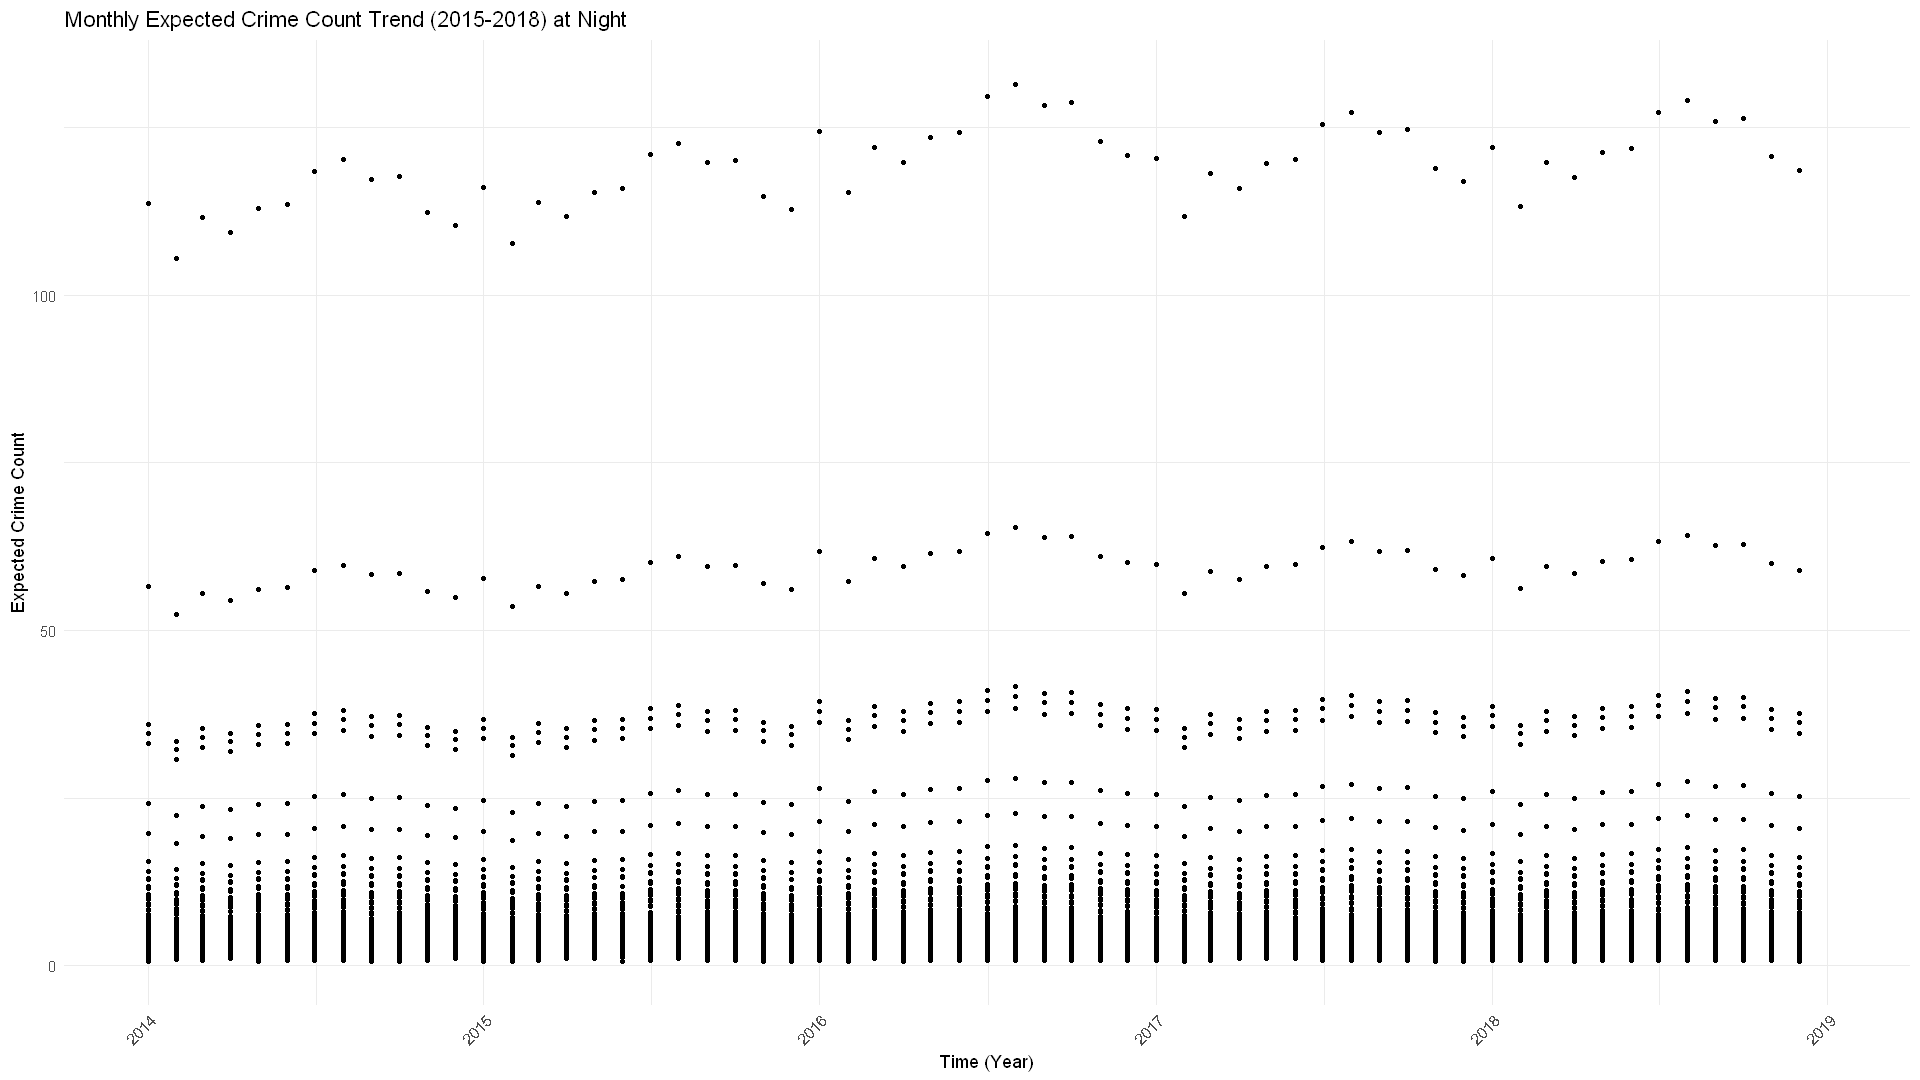

In [36]:
ggplot(census2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2018) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 27578 rows containing missing values or values outside the scale range
(`geom_point()`)."


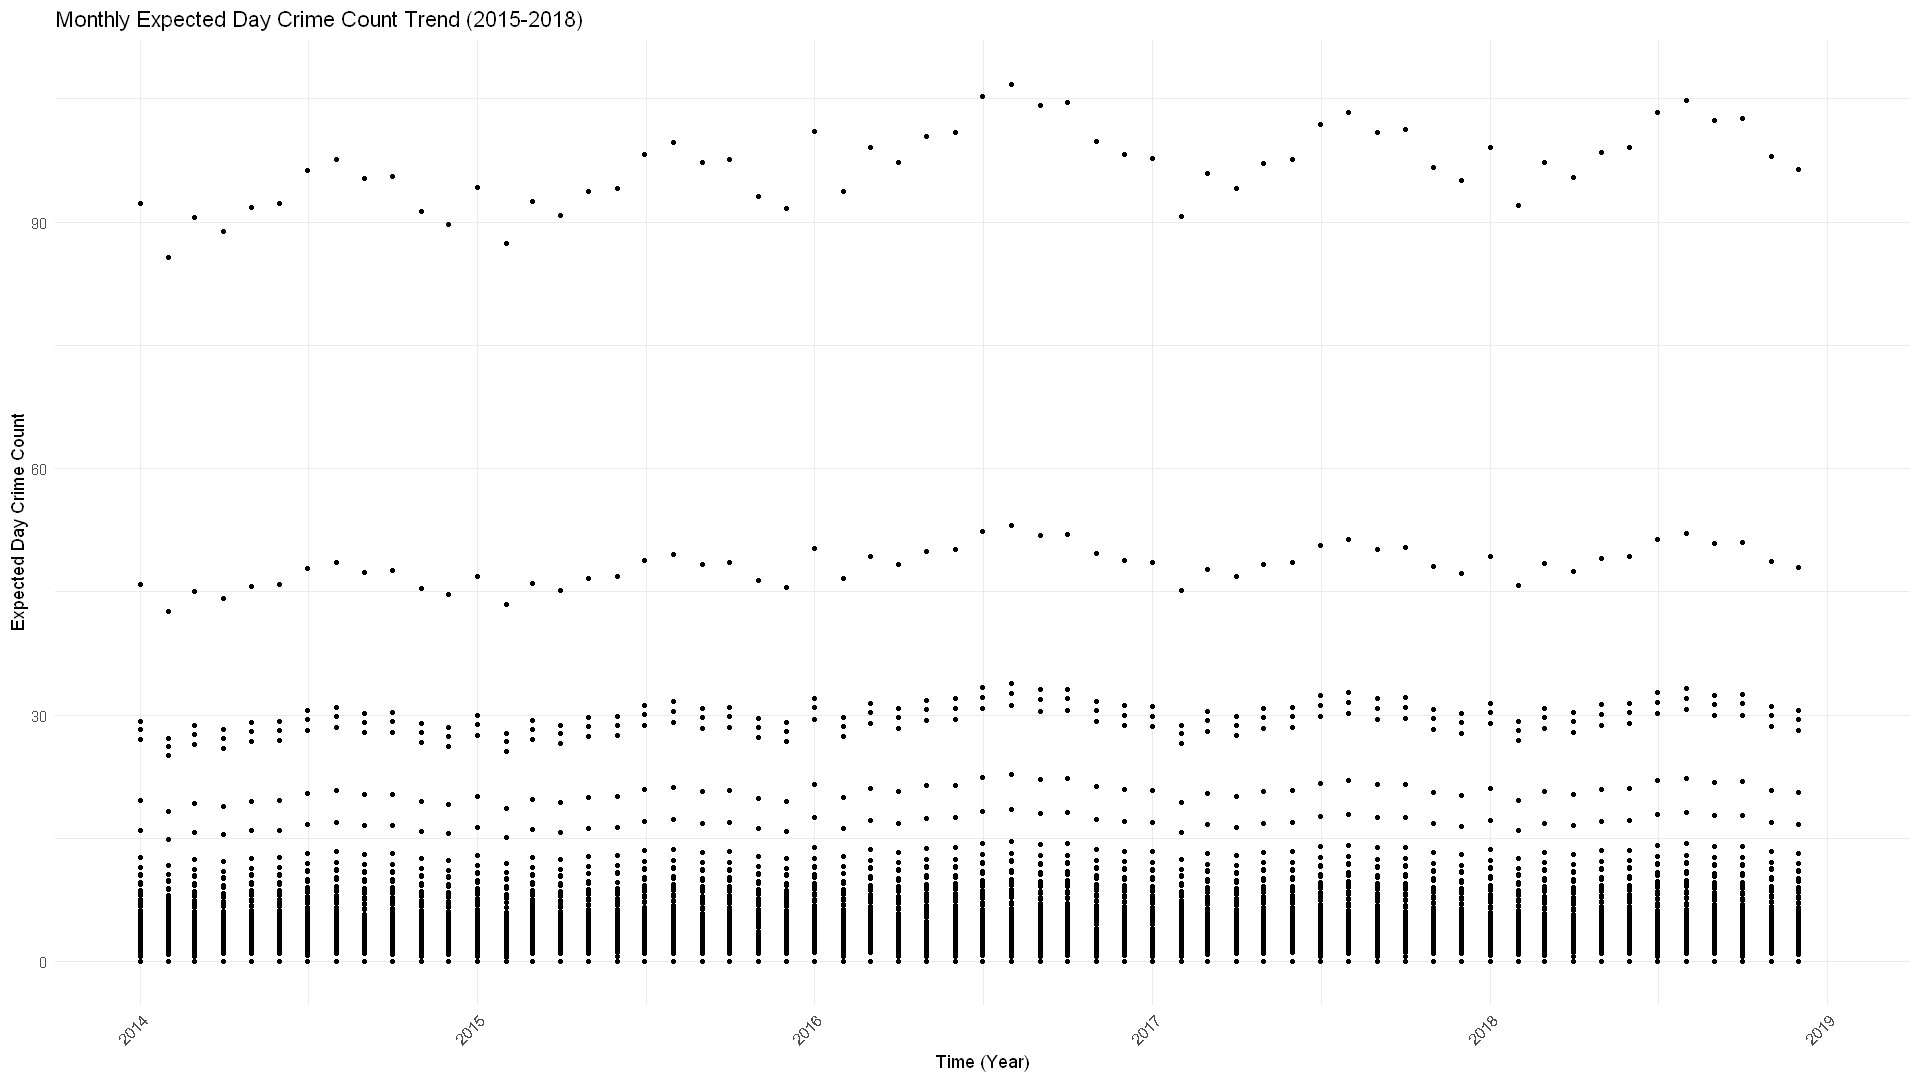

In [37]:
ggplot(census2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Day Crime Count", 
       title = "Monthly Expected Day Crime Count Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 30245 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 30245 rows containing missing values or values outside the scale range
(`geom_point()`)."


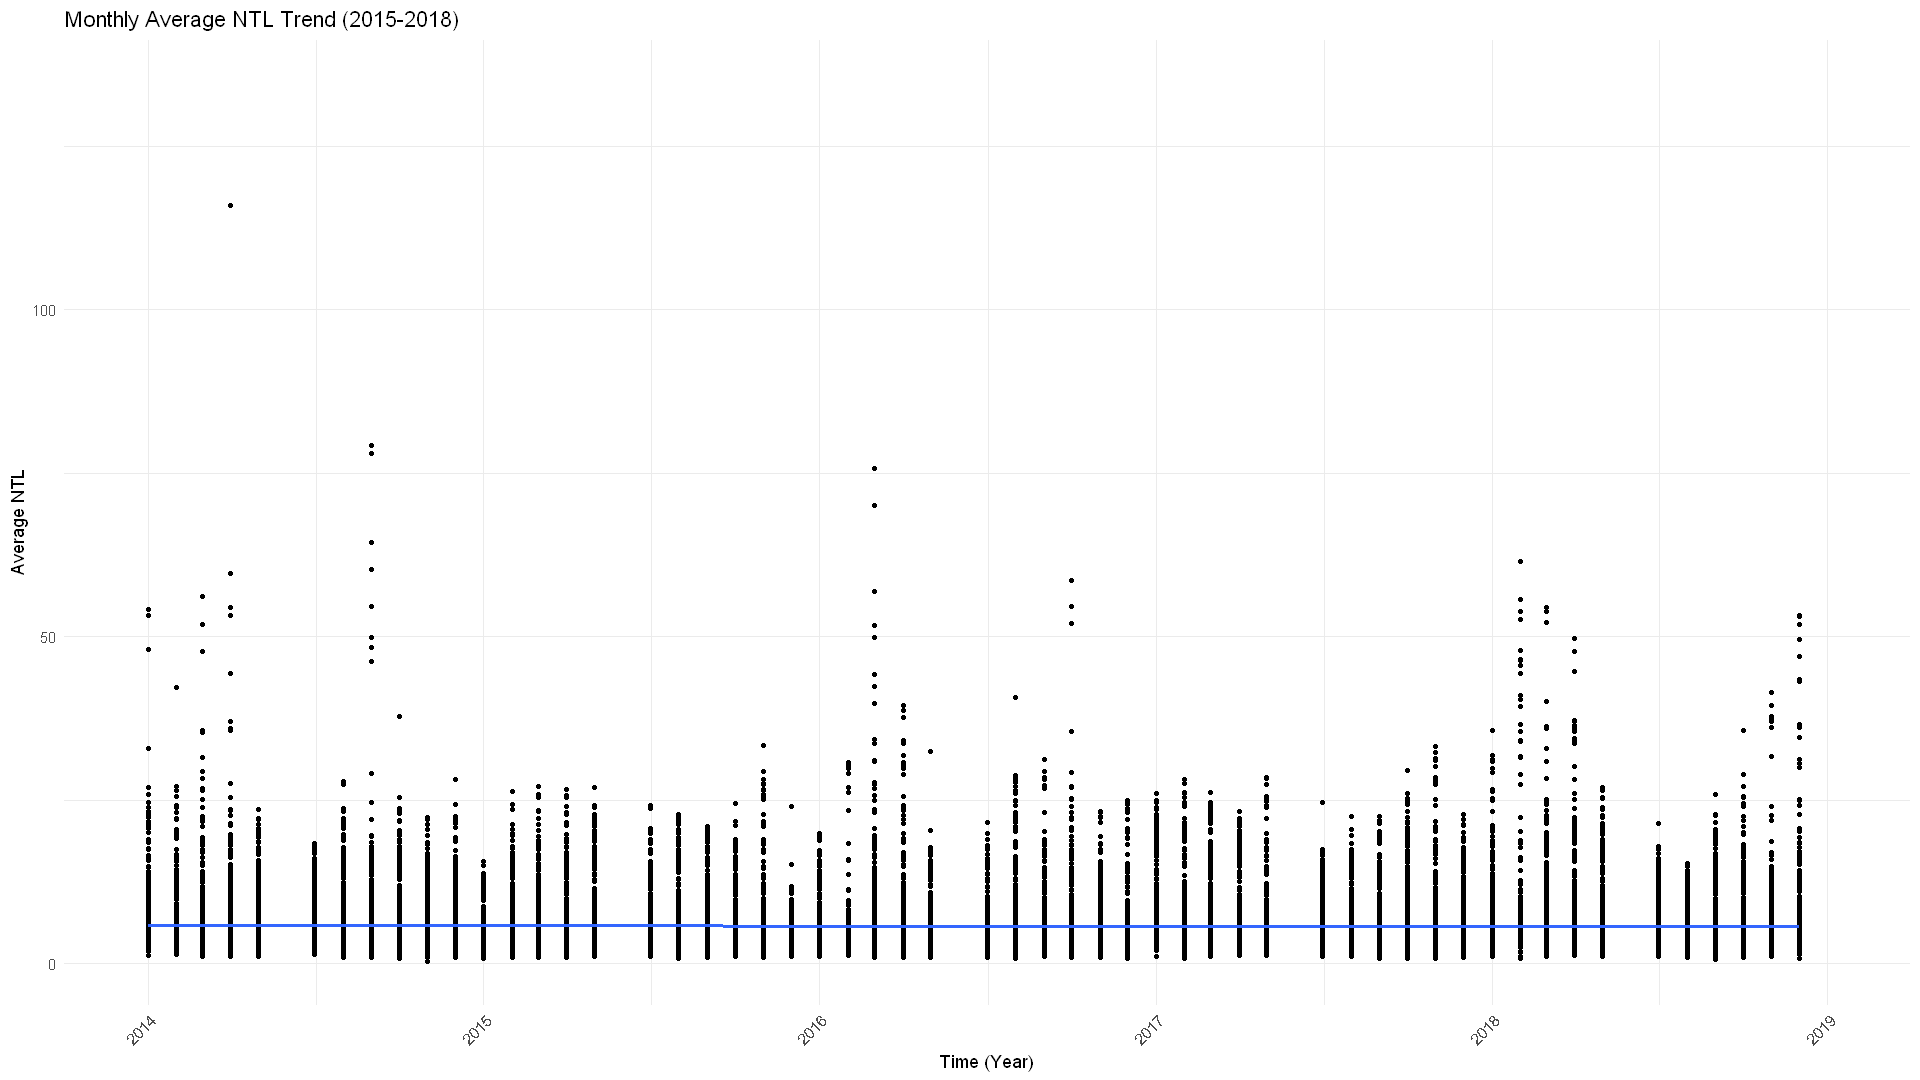

In [38]:
ggplot(census2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [39]:
library(plm)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead




In [40]:
model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-13.3256913  -0.0723774   0.0043409   0.0773481  12.0741901 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.00018223  0.00168708  -0.1080   0.91398    
year2015              0.06053619  0.00999404   6.0572 1.394e-09 ***
year2016              0.26299303  0.00994779  26.4373 < 2.2e-16 ***
year2017              0.16539276  0.00999037  16.5552 < 2.2e-16 ***
year2018              0.20754716  0.00992207  20.9177 < 2.2e-16 ***
year2019              0.38958828  0.01002093  38.8774 < 2.2e-16 ***
year2020             -0.08923967  0.01020019  -8.7488 < 2.2e-16 ***
year2021             -0.36

In [41]:
model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-11.791959  -0.150043  -0.020515   0.144630  10.573826 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean              0.0022965  0.0016501   1.3917  0.164013    
expected_day_crime    0.1575235  0.0015347 102.6440 < 2.2e-16 ***
month10               0.0819609  0.0104877   7.8150 5.596e-15 ***
month11              -0.0246228  0.0106068  -2.3214  0.020268 *  
month12              -0.0678607  0.0106201  -6.3899 1.674e-10 ***
month2               -0.1891077  0.0108142 -17.4870 < 2.2e-16 ***
month3               -0.0525447  0.0107704  -4.8786 1.071e-06 ***
month4               -0.1065844  0.010

In [42]:
model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month + electric_index + population_density, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-11.609156  -0.149931  -0.032888   0.150846  10.401095 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean              5.5222e-04  1.5663e-03   0.3526 0.7244106    
expected_day_crime    1.7255e-01  1.5307e-03 112.7270 < 2.2e-16 ***
month10               7.3897e-02  9.9805e-03   7.4042 1.338e-13 ***
month11              -3.4700e-02  1.0089e-02  -3.4394 0.0005834 ***
month12              -7.6125e-02  1.0100e-02  -7.5374 4.869e-14 ***
month2               -1.8599e-01  1.0251e-02 -18.1433 < 2.2e-16 ***
month3               -5.3455e-02  1.0209e-0

In [43]:
model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.890206 -0.081743  0.018107  0.079244  0.822777 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -0.02355856  0.00258103  -9.1276 < 2.2e-16 ***
expected_day_crime         0.01610750  0.00034547  46.6253 < 2.2e-16 ***
month10                    0.03750366  0.00236702  15.8443 < 2.2e-16 ***
month11                   -0.00581221  0.00238876  -2.4332   0.01497 *  
month12                   -0.02351866  0.00239181  -9.8330 < 2.2e-16 ***
month2                    -0.07285011  0.00245499 -29.6743 < 2.2e-16 ***
month3                    -0.01424970  0.00245

In [44]:
model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month + electric_index + population_density, 
    data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.6376362 -0.0706564 -0.0029254  0.0785201  0.6888408 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -1.8607e-02  2.3102e-03  -8.0543 8.153e-16 ***
expected_day_crime         1.4708e-02  3.2456e-04  45.3172 < 2.2e-16 ***
month10                    4.6108e-02  2.1215e-03  21.7339 < 2.2e-16 ***
month11                    1.8098e-03  2.1404e-03   0.8455   0.39781    
month12                   -1.5522e-02  2.1430e-03  -7.2430 4.445e-13 ***
month2                    -7.3479e-02  2.1925e-03 -33.5142 < 2.2e-16 ***
mo

We run robustness check on the unadjusted crime counts

In [45]:
model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month, 
    data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-42.15451  -0.71260  -0.24973   0.49782  59.76975 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean              0.0158702  0.0066510  2.3861 0.0170297 *  
year2015              0.0647829  0.0393996  1.6443 0.1001299    
year2016              0.3135168  0.0392173  7.9943 1.328e-15 ***
year2017              0.2403124  0.0393852  6.1016 1.057e-09 ***
year2018              0.3469959  0.0391160  8.8710 < 2.2e-16 ***
year2019              0.4591663  0.0395057 11.6228 < 2.2e-16 ***
year2020             -0.0332399  0.0402124 -0.8266 0.4084629    
year2021             -0.3411620  0.0421287 -8.0981 5.697e-16 ***
year2022

In [46]:
model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 11-110, N = 55766

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-38.76424  -0.67030  -0.30218   0.50642  59.72395 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean              0.0219270  0.0064729   3.3875 0.0007058 ***
day_crime_count       0.2144395  0.0043243  49.5889 < 2.2e-16 ***
month10              -0.1269895  0.0411773  -3.0840 0.0020436 ** 
month11              -0.0847796  0.0416402  -2.0360 0.0417545 *  
month12              -0.0296423  0.0416894  -0.7110 0.4770699    
month2               -0.2718743  0.0424508  -6.4045 1.521e-10 ***
month3               -0.2861644  0.0422884  -6.7670 1.328e-11 ***
month4               -0.4603736  0.0423615 -10.8677 < 

#### Models on 22 Neighborhoods

In [47]:
neighborhood2016_2021_panel <- read_csv("neighborhood2016_2021_panel.csv")

Rows: 5279 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (14): year, month, population, area_sq_km, population_density, income, ...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [48]:
neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income))|>
    filter(!is.na(income))|>
    glimpse()

Rows: 2,640
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

### 

In [49]:
# Adding day crime as a control
neighborhood2016_2021_panel_day <- neighborhood2016_2021_panel|>
    filter(time_category == "day")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(neighborhood, date, day_crime_count, expected_day_crime)

neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel_night|>
    left_join(neighborhood2016_2021_panel_day, by = c("date", "neighborhood"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 2,640
Columns: 19
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

Warning message:
"Removed 1320 rows containing missing values or values outside the scale range
(`geom_point()`)."


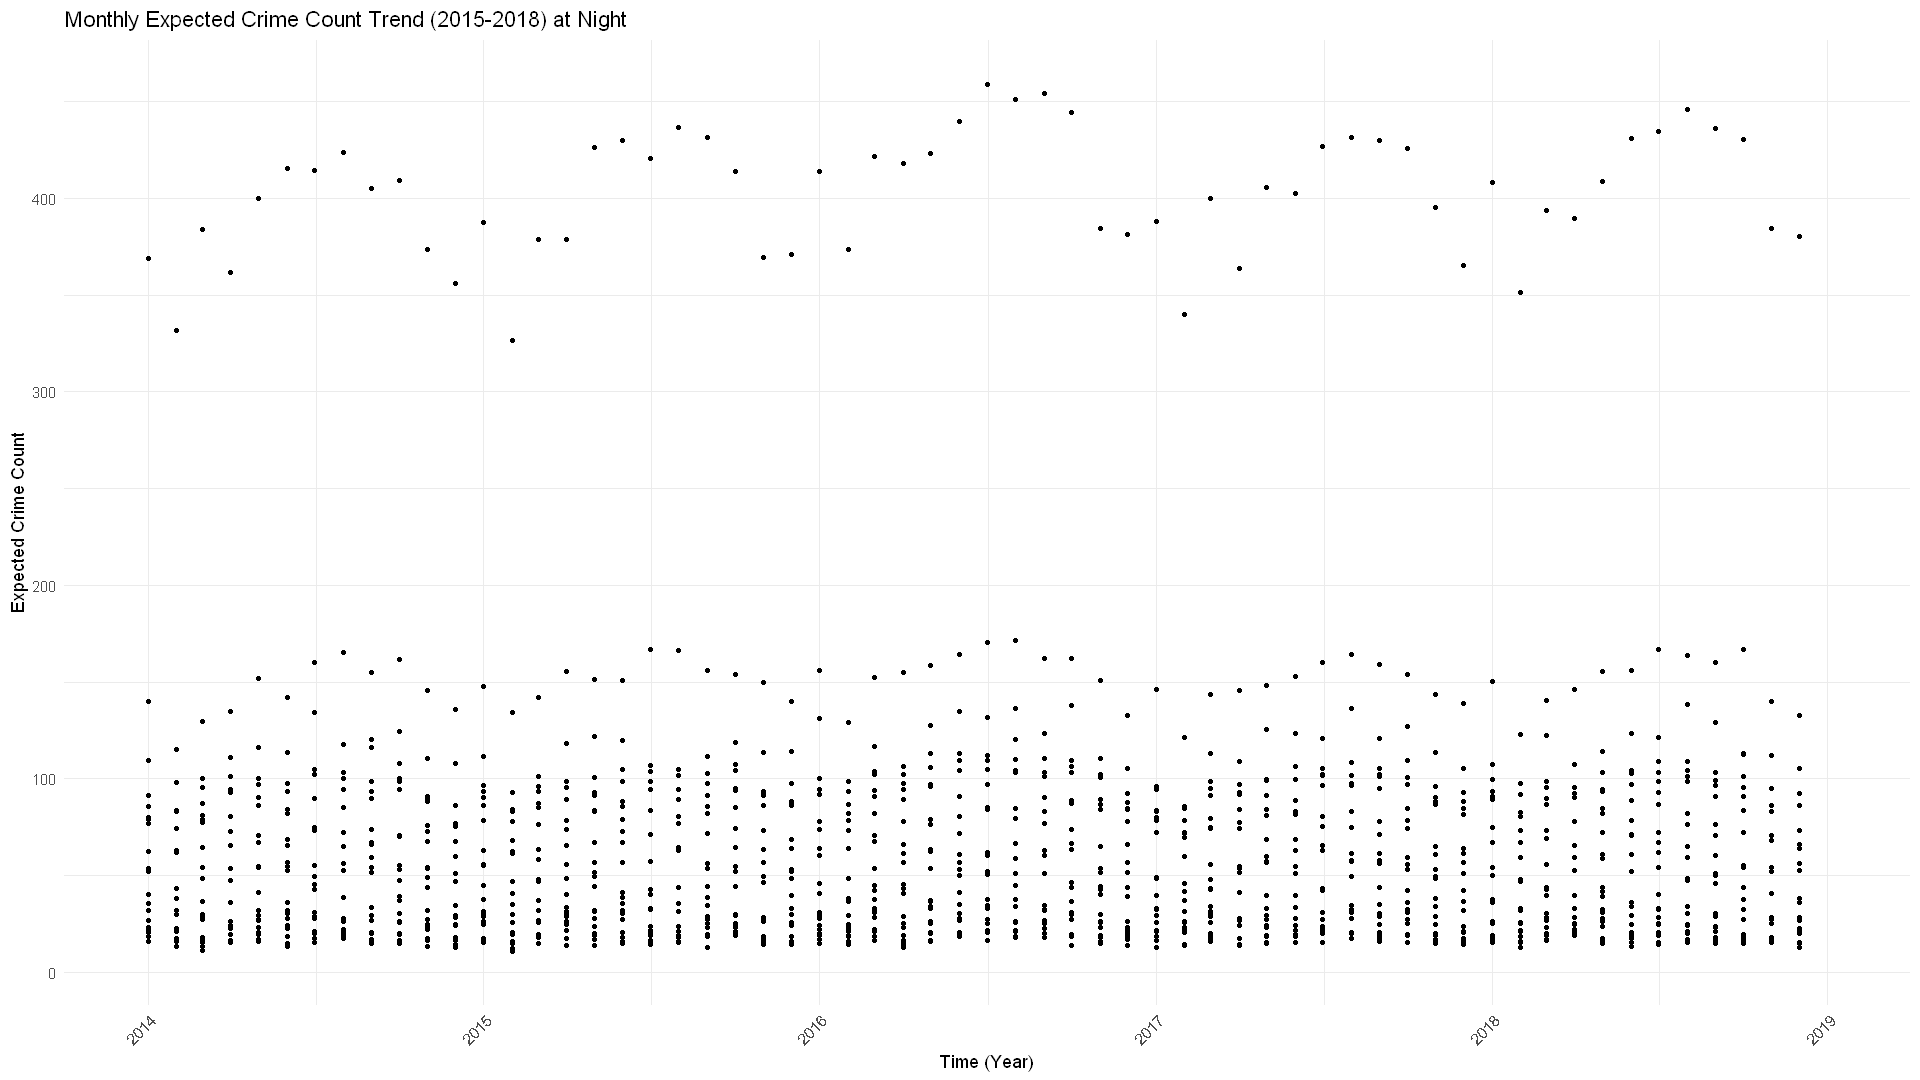

In [50]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2018) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 1320 rows containing missing values or values outside the scale range
(`geom_point()`)."


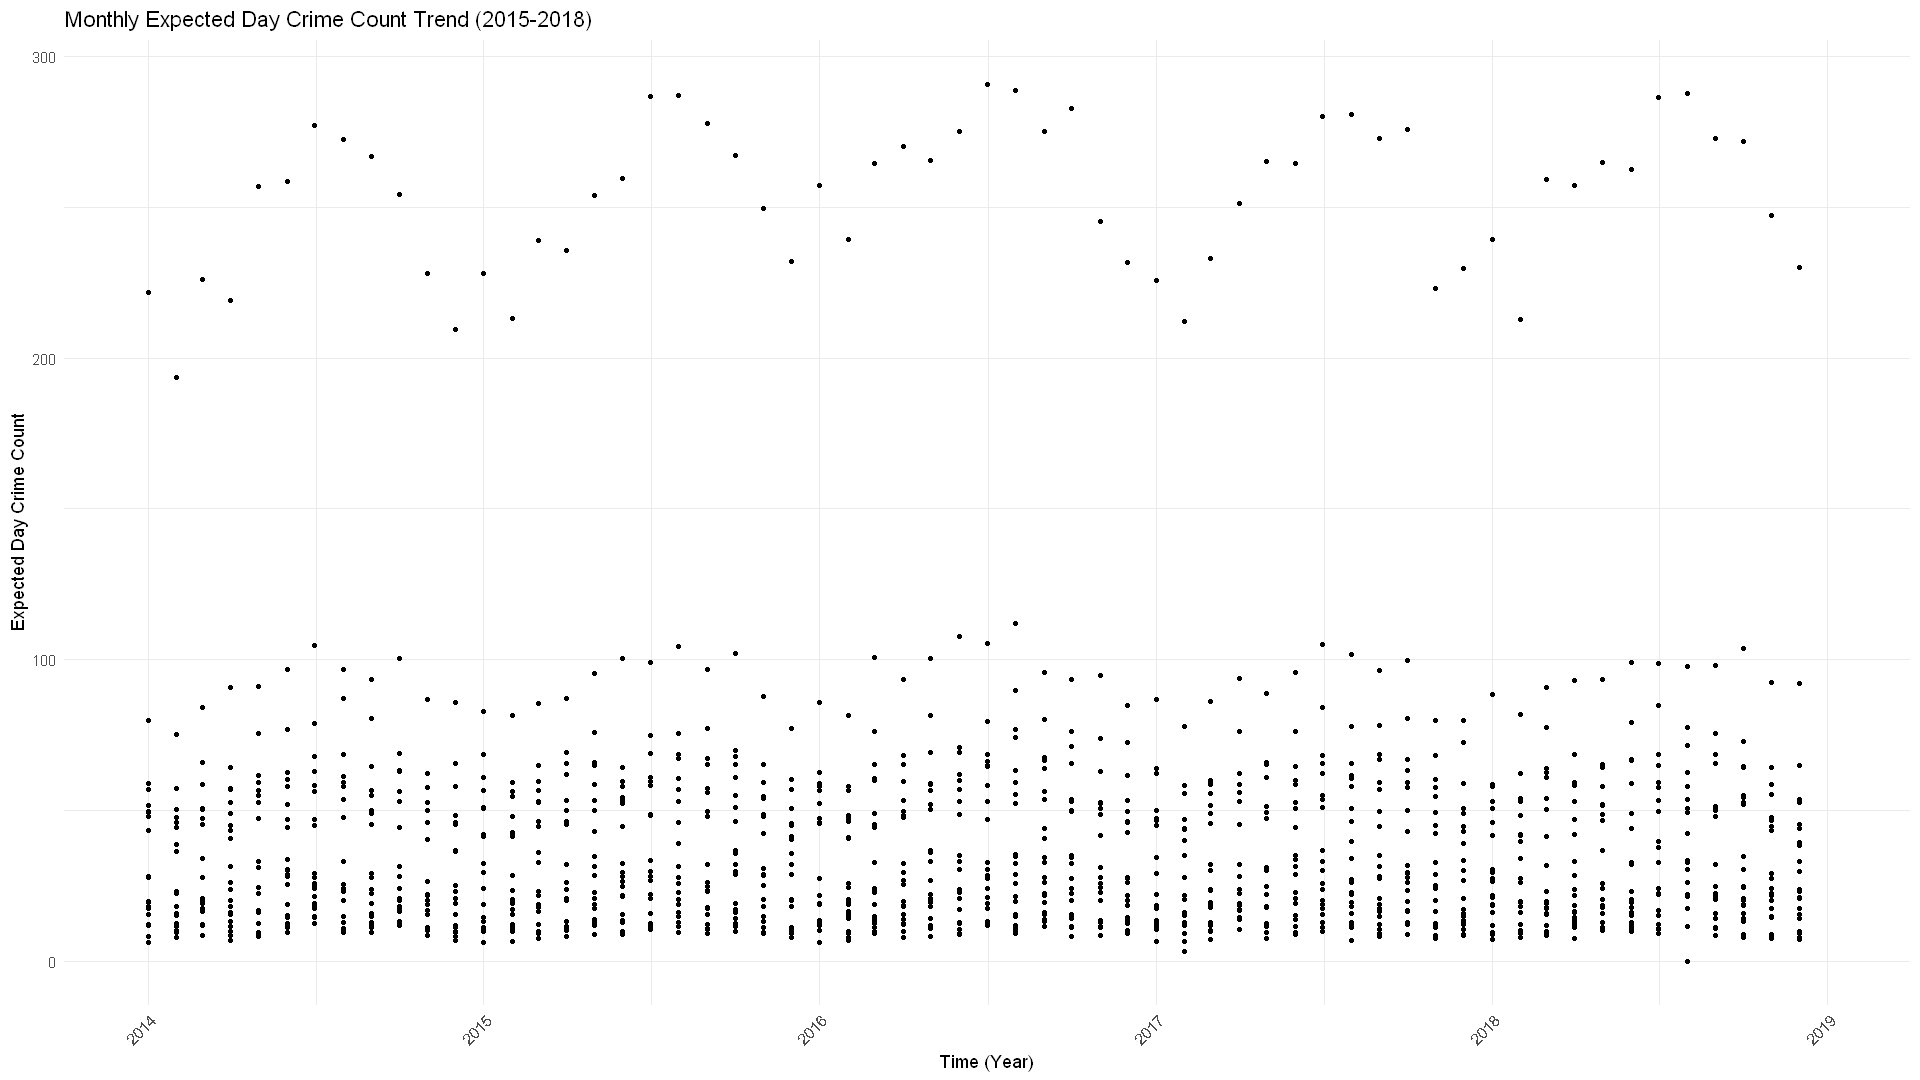

In [51]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Day Crime Count", 
       title = "Monthly Expected Day Crime Count Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 1430 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 1430 rows containing missing values or values outside the scale range
(`geom_point()`)."


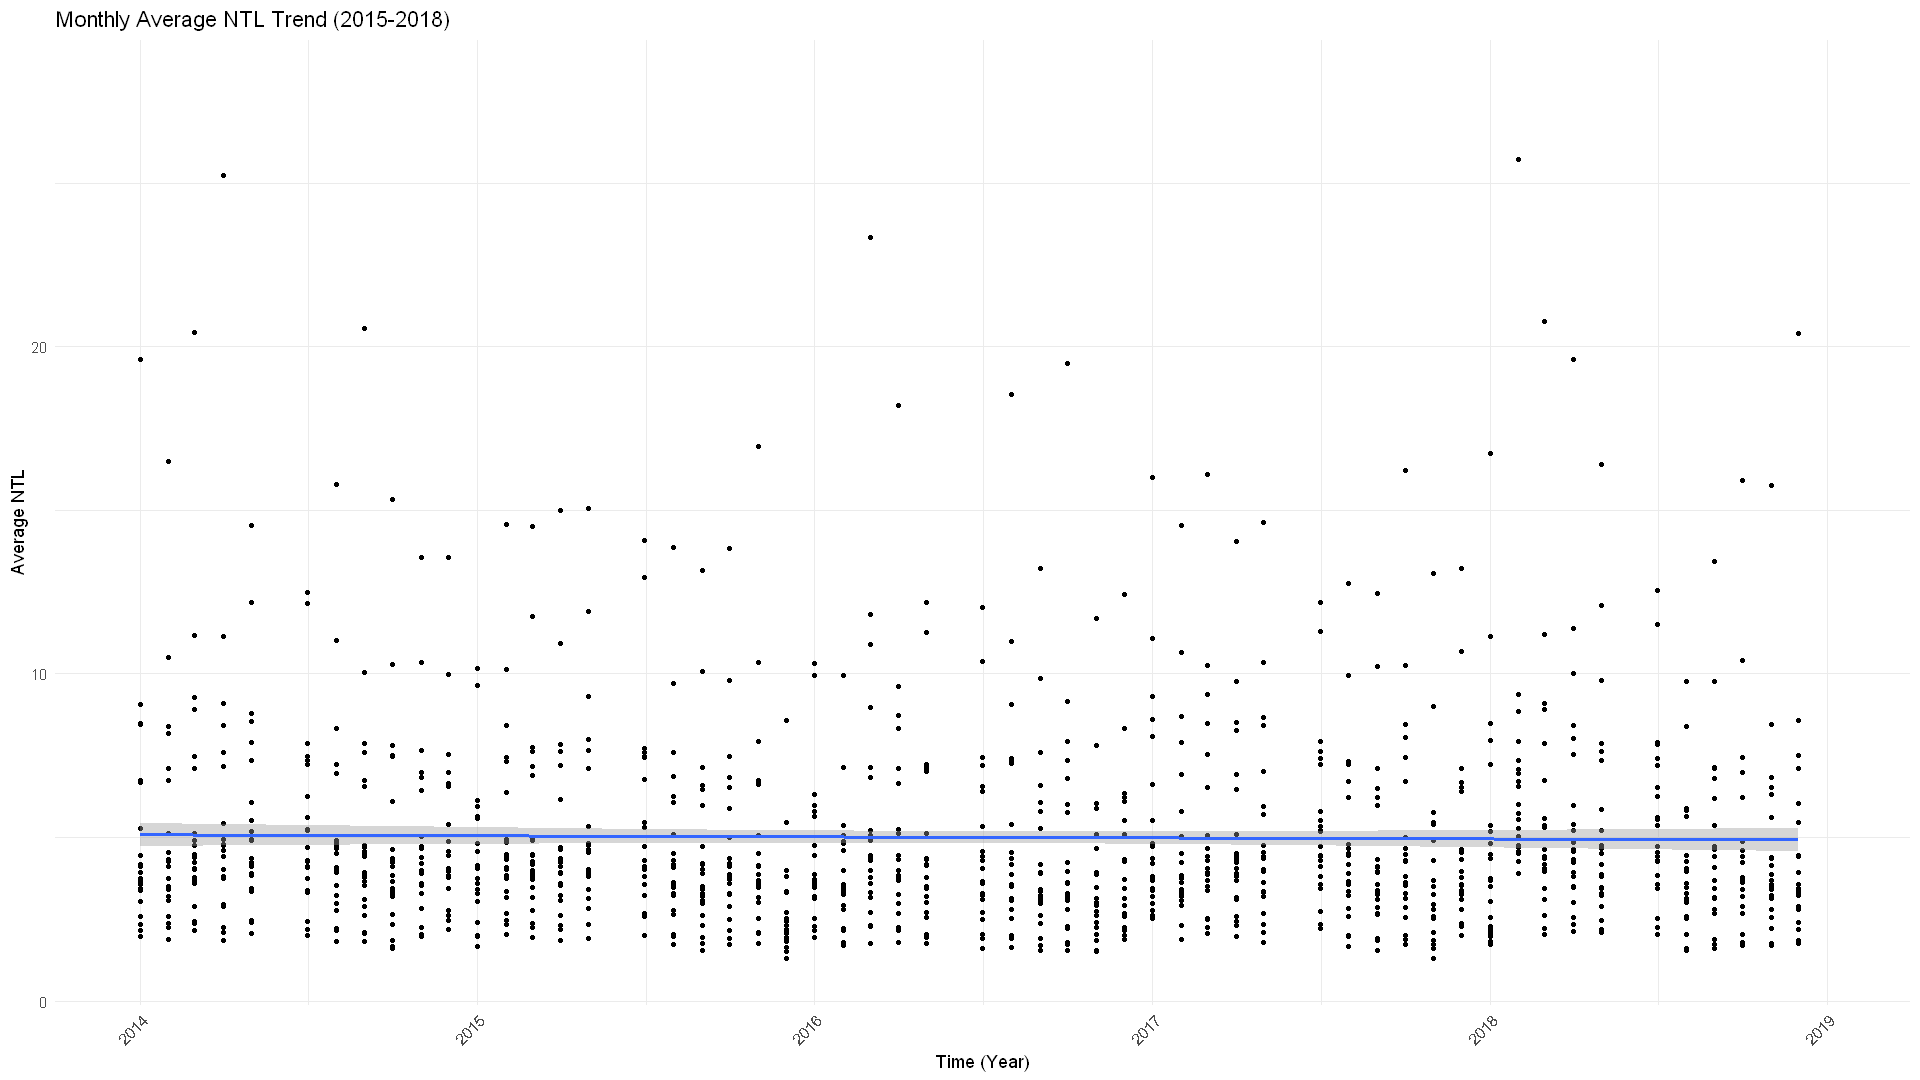

In [52]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [53]:
neighborhood_model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-117.2058   -6.4358   -0.6393    6.5498   95.4872 

Coefficients:
                      Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean               0.18623    0.45710   0.4074 0.6837323    
year2015               1.84161    1.45502   1.2657 0.2057468    
year2016               6.21552    1.46203   4.2513 2.208e-05 ***
year2017               1.89602    1.44793   1.3095 0.1905033    
year2018               2.40915    1.44379   1.6686 0.0953231 .  
year2019              -0.55113    1.44415  -0.3816 0.7027716    
year2020             -13.97351    1.44448  -9.6737 < 2.2e-16 ***
year2021             -25.95817    1.44429 -17.9730 < 2.2e-16 **

In [54]:
neighborhood_model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-83.06242  -5.04464  -0.63568   3.75911 150.32525 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean             -0.2133766  0.3393412 -0.6288 0.5295425    
expected_day_crime    0.4602524  0.0073264 62.8208 < 2.2e-16 ***
month10               4.0073309  1.1657687  3.4375 0.0005972 ***
month11              -0.9458041  1.1618451 -0.8141 0.4156956    
month12              -3.0933548  1.1611228 -2.6641 0.0077713 ** 
month2               -6.1727434  1.1804562 -5.2291 1.851e-07 ***
month3               -0.4490396  1.1904880 -0.3772 0.7060664    
month4               -0.6795208  1.1934534 -0.569

In [55]:
neighborhood_model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month + electric_index + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month + electric_index + population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-75.04607  -4.00554  -0.17736   3.00754 141.71131 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -0.27585080  0.30682039 -0.8991  0.368710    
expected_day_crime    0.48090045  0.00796766 60.3566 < 2.2e-16 ***
month10               4.39744210  1.05120907  4.1832 2.978e-05 ***
month11              -1.01519763  1.04743535 -0.9692  0.332533    
month12              -2.68249808  1.04681525 -2.5625  0.010452 *  
month2               -5.46408761  1.05955730 -5.1570 2.717e-07 ***
month3                0.07029102  1.06862805

In [56]:
neighborhood_model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.8435147 -0.0685877  0.0004332  0.0622132  0.6400489 

Coefficients:
                            Estimate Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -0.0236981  0.0209554  -1.1309 0.2582168    
year2015                   0.0268966  0.0131330   2.0480 0.0406675 *  
year2016                   0.0867655  0.0132244   6.5610 6.537e-11 ***
year2017                   0.0280066  0.0130337   2.1488 0.0317518 *  
year2018                   0.0268494  0.0129874   2.0673 0.0388093 *  
year2019                   0.0012075  0.0129862   0.0930 0.9259256    
year2020                  -0.2021554  0.0129955 -15.5558 < 2.2e-16

In [57]:
neighborhood_model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.029431 -0.143904  0.026556  0.140276  0.830958 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.17297371  0.03045249 -5.6801 1.510e-08 ***
expected_day_crime         0.00322784  0.00013002 24.8266 < 2.2e-16 ***
month10                    0.07170360  0.02074205  3.4569 0.0005560 ***
month11                   -0.01234765  0.02065963 -0.5977 0.5501166    
month12                   -0.06339526  0.02064297 -3.0710 0.0021573 ** 
month2                    -0.09477192  0.02119490 -4.4714 8.133e-06 ***
month3                     0.02629804  0.02132

In [58]:
neighborhood_model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month + electric_index + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month + electric_index + population_density + 
    income, data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.5534900 -0.1001604  0.0061465  0.0851499  0.4765785 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -7.0162e-02  2.1026e-02  -3.3368 0.0008604 ***
expected_day_crime         1.3593e-03  1.0794e-04  12.5928 < 2.2e-16 ***
month10                    1.0746e-01  1.4269e-02   7.5308 7.115e-14 ***
month11                    6.0163e-03  1.4210e-02   0.4234 0.6720552    
month12                   -3.1429e-02  1.4200e-02  -2.2134 0.0269662 *  
month2                    -9.8756e-02  1.4518e-02  -6.8025 

We check the robustness by running models on crime counts.